Usando os conhecimentos da atividade passada (implementação de MLP) e das aulas, implemente uma Rede Convolucional (CNN) - usando PyTorch, TensorFlow ou “do zero” -  com a arquitetura que desejar. Você pode e deve usar técnicas de regularização. Avalie o desempenho da sua rede no conjuntos de dados MNIST e CIFAR10 e elabore um documento com a comparação de desempenho preditivo entre a sua rede e uma rede pré-treinada conhecida de sua escolha (por exemplo AlexNet, VGG16, ResNet50). A rede pré-treinada pode ser encontrada no próprio PyTorch/TensorFlow ou baixada de outro lugar. Neste documento, discuta e justifique as razões para os resultados obtidos. Argumente também sobre o que você pode fazer para melhorar o desempenho preditivo da sua CNN. É desejável que o documento tenha gráficos para a melhor visualização dos resultados.

O que submeter nesta atividade?

Documento com a comparação entre as CNNs.
Link para o repositório com o código-fonte das CNNs e dos seus experimentos.

DESAFIO: Plotar as ativações dos kernels para uma melhor visualização do que cada neurônio está aprendendo.


## import das bibliotecas

In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
import torchvision.models as models
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import optuna
from fvcore.nn import FlopCountAnalysis
from plotly.io import show
from pathlib import Path
import sys

from RepeatChannels import RepeatChannels


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import numpy as np
import random
np.random.seed(SEED)
random.seed(SEED)

Using device: cpu


## Códigos para criação da rede CNN, otimização da rede e otimização de hiperparâmetros

In [3]:
class CNNParameters:
    def __init__(self, num_conv_layers, stride_conv_layers, input_channels, out_channels_list, use_pooling,
                 padding_conv_layer, dilatation, bias, kernel_size, kernel_stride,
                 kernel_padding, kernel_dilatation, activation_function_conv, fully_connected_layers_list,
                 activation_function_fully_connected, dropout_rate_fully_connected, dropout_rate_conv, output_size_fully_connected,
                 image_size_height, image_size_width
                 ):
        # cnn parameters
        self.num_conv_layers = num_conv_layers
        self.stride_conv_layers = stride_conv_layers
        self.input_channels = input_channels
        self.out_channels_list = out_channels_list
        self.dropout_rate_conv = dropout_rate_conv
        self.padding_conv_layer = padding_conv_layer
        self.dilatation = dilatation
        self.bias = bias
        self.activation_function_conv = activation_function_conv

        # polling parameters
        self.use_pooling = use_pooling
        self.kernel_size = kernel_size
        self.kernel_stride = kernel_stride
        self.kernel_padding = kernel_padding
        self.kernel_dilatation = kernel_dilatation

        # fully connected layers parameters
        self.fully_connected_layers_list = fully_connected_layers_list
        self.activation_function_fully_connected = activation_function_fully_connected
        self.dropout_rate_fully_connected = dropout_rate_fully_connected
        self.output_size_fully_connected = output_size_fully_connected

        #flatten size
        self.image_size_height = image_size_height
        self.image_size_width = image_size_width
        self.image_size_height_output = 0
        self.image_size_width_output = 0
        self.image_size_height_output, self.image_size_width_output = self._calculate_output_size(image_size_height, image_size_width)
        self.flatten_size = self.image_size_height_output * self.image_size_width_output * self.out_channels_list[-1]

    def _calculate_output_size(self, input_size_height, input_size_width):
        output_size_height = input_size_height
        output_size_width = input_size_width
        for i in range(self.num_conv_layers):
            output_size_height = (output_size_height + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            output_size_width = (output_size_width + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            if self.use_pooling:
                output_size_height = (output_size_height + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
                output_size_width = (output_size_width + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
        return output_size_height, output_size_width

In [4]:
map_activation_functions = {
    'relu': nn.ReLU,
    'sigmoid': nn.Sigmoid,
    'tanh': nn.Tanh,
    'leaky_relu': nn.LeakyReLU,
}
map_optimizers = {
    'adam': torch.optim.Adam,
    'sgd': torch.optim.SGD,
    'rmsprop': torch.optim.RMSprop,
}
def get_activation_function(name):
    return map_activation_functions[name]()

In [5]:
class CNN(nn.Module):
    def __init__(self, cnn_parameters: CNNParameters):
        super(CNN, self).__init__()
        self.cnn_parameters = cnn_parameters

        layers = []

        for i in range(self.cnn_parameters.num_conv_layers):
            layers.append(nn.Conv2d(in_channels=self.cnn_parameters.input_channels if i == 0 else self.cnn_parameters.out_channels_list[i-1],
                                    out_channels=self.cnn_parameters.out_channels_list[i],
                                    kernel_size=self.cnn_parameters.kernel_size,
                                    stride=self.cnn_parameters.stride_conv_layers,
                                    padding=self.cnn_parameters.padding_conv_layer,
                                    dilation=self.cnn_parameters.dilatation,
                                    bias=self.cnn_parameters.bias))
            layers.append(get_activation_function(self.cnn_parameters.activation_function_conv))

            if self.cnn_parameters.dropout_rate_conv > 0:
                layers.append(nn.Dropout2d(self.cnn_parameters.dropout_rate_conv))

            if self.cnn_parameters.use_pooling:
                layers.append(nn.MaxPool2d(kernel_size=self.cnn_parameters.kernel_size,
                                           stride=self.cnn_parameters.kernel_stride,
                                           padding=self.cnn_parameters.kernel_padding,
                                           dilation=self.cnn_parameters.kernel_dilatation))
        
        self.conv_layers = nn.Sequential(*layers)
        
        fully_connected_layers = []
        input_size_fully_connected = cnn_parameters.flatten_size

        for output_size in self.cnn_parameters.fully_connected_layers_list:
            fully_connected_layers.append(nn.Linear(input_size_fully_connected, output_size))
            fully_connected_layers.append(get_activation_function(self.cnn_parameters.activation_function_fully_connected))
            if self.cnn_parameters.dropout_rate_fully_connected > 0:
                fully_connected_layers.append(nn.Dropout(self.cnn_parameters.dropout_rate_fully_connected))
            input_size_fully_connected = output_size
        
        fully_connected_layers.append(nn.Linear(input_size_fully_connected, self.cnn_parameters.output_size_fully_connected))
        self.fully_connected_layers = nn.Sequential(*fully_connected_layers)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.flatten(start_dim=1)
        x = self.fully_connected_layers(x)
        return x
            
        

In [6]:
# função para avaliar o modelo no conjunto de teste
def evaluate_model(model, test_dataloader, metric_fn=metrics.accuracy_score, device=device):
    model.eval()
    y = []
    y_pred = []
    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            y.extend(y_batch.detach().cpu().tolist())
            y_pred.extend(predicted.detach().cpu().tolist())
    metric_val = metric_fn(y, y_pred)
    return metric_val

In [7]:
# função para treinar o modelo, recebe como entrada o modelo, os dataloaders de treino e validação, a função de perda, o otimizador e o número de épocas e o critério de parada
# a função também salva o histórico da função de perda para treino e validação
def train_model(model, train_dataloader, val_dataloader, loss_fn, optimizer, num_epochs, patience, metric_fn=None, device=device, verbose=False):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history_train_loss = []
    history_val_loss = []
    history_val_metric = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        history_train_loss.append(avg_train_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}')

        # validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history_val_loss.append(avg_val_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}')

        # avaliando a métrica de validação
        if metric_fn is not None:
            metric_val = evaluate_model(model, val_dataloader, metric_fn=metric_fn, device=device)
            history_val_metric.append(metric_val)
            if verbose and epoch % 5 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Validation Metric: {metric_val:.4f}')

        # critério de parada
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return history_train_loss, history_val_loss, history_val_metric

In [8]:
# função para criação do modelo, e definição dos hiperparâmetros do modelo e dataloaders
def create_model_and_dataloaders( cnn_parameters,train_data, test_data, val_data, batch_size):
    model = CNN(cnn_parameters)
    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
    val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
    return model, train_dataloader, test_dataloader, val_dataloader

In [9]:
def split_train_val_dataset(dataset, val_size, random_state=42):
    labels = np.asarray(dataset.targets)
    indices = np.arange(len(dataset))
    train_idx, val_idx = train_test_split(indices, test_size=val_size, random_state=random_state, stratify=labels)
    return Subset(dataset, train_idx), Subset(dataset, val_idx)

In [10]:
def plot_loss_graph(history_train_loss, history_val_loss, history_val_metric):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_train_loss, label='Train Loss')
    ax1.plot(history_val_loss, label='Val Loss')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend()

    if history_val_metric:
        ax2.plot(history_val_metric, label='Val Accuracy', color='green')
        ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy')
        ax2.set_title('Validation Accuracy'); ax2.legend()
    plt.tight_layout(); plt.show()

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(model, dataloader, class_names, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X, y in dataloader:
            preds = model(X.to(device)).argmax(1)
            y_true.extend(y.tolist())
            y_pred.extend(preds.cpu().tolist())
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.tight_layout()
    plt.show()

In [12]:
import time

# Função para contar parâmetros
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_parameters(model):
    return sum(p.numel() for p in model.parameters())

# Função para visualizar ativações de kernels (feature maps)
def visualize_feature_maps(model, input_image, layer_name, device):
    """Visualiza as ativações dos kernels de uma camada específica"""
    model.eval()
    
    # Hook para capturar a saída da camada
    activations = []
    def hook(module, input, output):
        activations.append(output.detach())
    
    # Registrar o hook na camada desejada
    for name, module in model.named_modules():
        if name == layer_name:
            module.register_forward_hook(hook)
            break
    
    # Forward pass
    with torch.no_grad():
        input_image = input_image.to(device)
        model(input_image)
    
    if not activations:
        print(f"Camada {layer_name} não encontrada")
        return None
    
    activation = activations[0][0]  # (channels, height, width)
    num_channels = activation.shape[0]
    
    # Plotar as primeiras 16 ativações
    n_display = min(16, num_channels)
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    for i in range(n_display):
        feature_map = activation[i].cpu().numpy()
        axes[i].imshow(feature_map, cmap='viridis')
        axes[i].set_title(f'Kernel {i}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return activation

# Função para comparação detalhada de modelos
def compare_models_detailed(model1, model2, dataloader1, dataloader2, name1, name2, device):
    """Compara dois modelos em detalhes"""
    
    # Número de parâmetros
    params1 = count_parameters(model1)
    params2 = count_parameters(model2)
    total_params1 = count_total_parameters(model1)
    total_params2 = count_total_parameters(model2)
    
    # Tempo de inferência (estimado)
    model1.eval()
    model2.eval()
    
    times1 = []
    times2 = []
    
    with torch.no_grad():
        for X, _ in dataloader1:
            X = X.to(device)
            start = time.time()
            _ = model1(X)
            times1.append(time.time() - start)
            if len(times1) >= 5:  # Apenas 5 batches para estimativa
                break
        
        for X, _ in dataloader2:
            X = X.to(device)
            start = time.time()
            _ = model2(X)
            times2.append(time.time() - start)
            if len(times2) >= 5:
                break
    
    avg_time1 = sum(times1) / len(times1) if times1 else 0
    avg_time2 = sum(times2) / len(times2) if times2 else 0
    
    comparison = {
        'model_name': [name1, name2],
        'trainable_params': [params1, params2],
        'total_params': [total_params1, total_params2],
        'avg_inference_time_ms': [avg_time1 * 1000, avg_time2 * 1000],
    }
    
    return comparison


## MNIST

### Download e preparação do dataset

In [13]:
training_data = datasets.MNIST(
    root="./../datasets",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.MNIST(
    root="./../datasets",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

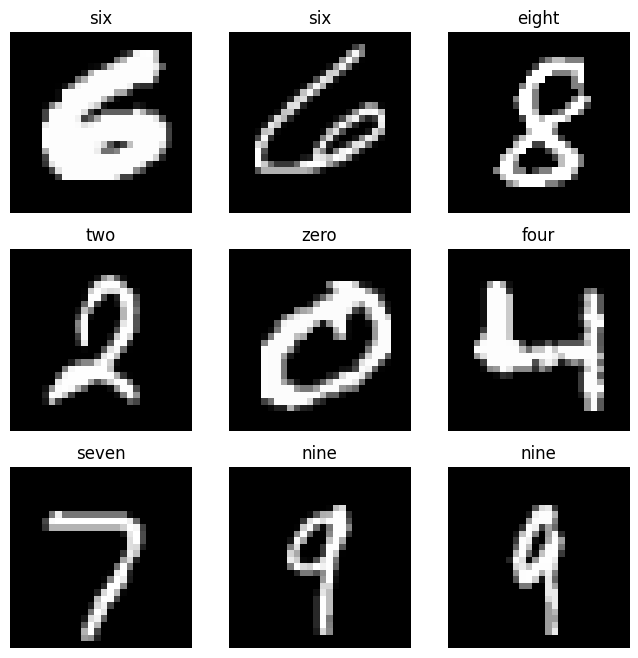

Training data size: 60000
Test data size: 10000


In [14]:
labels_map = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()
print(f"Training data size: {len(training_data)}")
print(f"Test data size: {len(test_data)}")

In [15]:
# Split the training data into training and validation sets
train_data, val_data = split_train_val_dataset(training_data, val_size=1.0/6.0)
print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")

Training set size: 50000
Validation set size: 10000


### Função de otimização de hiperparâmetros e execução da busca do melhor modelo

In [16]:
def objectiveMNIST(trial):
    """
    Otimiza uma CNN pequena para MNIST procurando um compromisso entre
    melhor acurácia e menor complexidade do modelo.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)
    out_channels_list = []
    for i in range(num_conv_layers):
        out_channels = trial.suggest_categorical(f'out_channels_layer_{i}', [8, 16, 32, 64])
        out_channels_list.append(out_channels)

    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    stride_conv = trial.suggest_categorical('stride_conv', [1, 2])
    padding_conv = trial.suggest_categorical('padding_conv', [0, 1, 2])
    dilatation = 1
    bias = True

    use_pooling = trial.suggest_categorical('use_pooling', [True, False])
    kernel_stride_pool = 1
    kernel_padding_pool = 0
    kernel_dilatation_pool = 1

    activation_function_conv = trial.suggest_categorical('activation_function_conv', ['relu', 'leaky_relu', 'tanh'])
    use_dropout_conv = trial.suggest_categorical('use_dropout_conv', [True, False])
    if use_dropout_conv:
        dropout_rate_conv = trial.suggest_float('dropout_rate_conv', 0.1, 0.6)
    else:        
        dropout_rate_conv = 0.0

    num_fc_layers = trial.suggest_int('num_fc_layers', 1, 3)
    fully_connected_layers_list = []
    for i in range(num_fc_layers):
        fc_units = trial.suggest_categorical(f'fc_units_{i}', [16, 32, 64, 128, 256])
        fully_connected_layers_list.append(fc_units)

    activation_function_fc = trial.suggest_categorical('activation_function_fc', ['relu', 'leaky_relu', 'tanh', 'sigmoid'])
    use_dropout_fc = trial.suggest_categorical('use_dropout_fc', [True, False])
    if use_dropout_fc:
        dropout_rate_fc = trial.suggest_float('dropout_rate_fc', 0.1, 0.6)
    else:
        dropout_rate_fc = 0.0

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    use_weight_decay = trial.suggest_categorical('use_weight_decay', [True, False])
    if use_weight_decay:
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    else:
        weight_decay = 0.0
    num_epochs = 10000
    patience = 15

    try:
        img_shape = training_data[0][0].shape  # (C, H, W)
        image_size_height=img_shape[1]
        image_size_width=img_shape[2]
        cnn_params = CNNParameters(
            num_conv_layers=num_conv_layers,
            stride_conv_layers=stride_conv,
            input_channels=1,
            out_channels_list=out_channels_list,
            use_pooling=use_pooling,
            padding_conv_layer=padding_conv,
            dilatation=dilatation,
            bias=bias,
            kernel_size=kernel_size,
            kernel_stride=kernel_stride_pool,
            kernel_padding=kernel_padding_pool,
            kernel_dilatation=kernel_dilatation_pool,
            activation_function_conv=activation_function_conv,
            fully_connected_layers_list=fully_connected_layers_list,
            activation_function_fully_connected=activation_function_fc,
            dropout_rate_fully_connected=dropout_rate_fc,
            dropout_rate_conv=dropout_rate_conv,
            output_size_fully_connected=10,
            image_size_height=image_size_height,
            image_size_width=image_size_width
        )

        if cnn_params.image_size_height_output <= 0 or cnn_params.image_size_width_output <= 0:
            return 0.0, float('inf')

        model, train_dataloader, test_dataloader, val_dataloader = create_model_and_dataloaders(
            cnn_params, train_data, test_data, val_data, batch_size
        )
        model = model.to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer_cls = map_optimizers[optimizer_name]
        if optimizer_name == 'sgd':
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
        else:
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        history_train_loss, history_val_loss, history_val_metric = train_model(
            model,
            train_dataloader,
            val_dataloader,
            loss_fn,
            optimizer,
            num_epochs=num_epochs,
            patience=patience,
            metric_fn=metrics.accuracy_score,
            device=device,
        )

        val_accuracy = evaluate_model(model, val_dataloader, metric_fn=metrics.accuracy_score, device=device)
        flops = FlopCountAnalysis(model.cpu(), torch.randn(1, 1, 28, 28).cpu(),).total()

        return val_accuracy, flops

    except Exception as e:
        print(f"Erro durante a execução do trial: {e}")
        return 0.0, float('inf')

In [17]:
SEED = 42
sampler = optuna.samplers.TPESampler(seed=SEED)
study_mnist = optuna.create_study(directions=['maximize', 'minimize'], sampler=sampler)
study_mnist.optimize(objectiveMNIST, n_trials=25, show_progress_bar=True, n_jobs=1)

[I 2026-05-18 14:05:08,249] A new study created in memory with name: no-name-162bbb6a-9f43-4f0e-908c-d90e86914bbf


  0%|          | 0/25 [00:00<?, ?it/s]

Unsupported operator aten::tanh encountered 2 time(s)


[I 2026-05-18 14:12:39,033] Trial 0 finished with values: [0.1124, 1976352.0] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 8, 'out_channels_layer_1': 32, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 0, 'use_pooling': False, 'activation_function_conv': 'tanh', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 256, 'activation_function_fc': 'relu', 'use_dropout_fc': True, 'dropout_rate_fc': 0.16101911742238942, 'batch_size': 128, 'learning_rate': 0.0061394260508981545, 'optimizer': 'rmsprop', 'use_weight_decay': False}.
[I 2026-05-18 14:12:39,041] Trial 1 finished with values: [0.0, inf] and parameters: {'num_conv_layers': 3, 'out_channels_layer_0': 8, 'out_channels_layer_1': 64, 'out_channels_layer_2': 32, 'kernel_size': 5, 'stride_conv': 2, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.27923286427213634, 'num_fc_layers': 1, 'fc_units_0': 16, 'activation_f

Unsupported operator aten::tanh encountered 4 time(s)


...

[I 2026-05-18 22:58:20,440] Trial 21 finished with values: [0.9813, 1363712.0] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 8, 'out_channels_layer_1': 16, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 1, 'use_pooling': False, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 64, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.2390658859897092, 'batch_size': 32, 'learning_rate': 0.0002963790632894457, 'optimizer': 'adam', 'use_weight_decay': True, 'weight_decay': 0.00019691576222746027}.


Unsupported operator aten::leaky_relu encountered 2 time(s)
Unsupported operator aten::tanh encountered 2 time(s)


[I 2026-05-18 23:15:41,230] Trial 22 finished with values: [0.9851, 5455776.0] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 8, 'out_channels_layer_1': 16, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 256, 'fc_units_1': 64, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.22627629229443103, 'batch_size': 32, 'learning_rate': 0.0003775423875193288, 'optimizer': 'adam', 'use_weight_decay': False}.
[I 2026-05-18 23:15:41,269] Trial 23 finished with values: [0.0, inf] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 8, 'out_channels_layer_1': 16, 'kernel_size': 5, 'stride_conv': 2, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 64, 'activation_function_fc': 'tanh', 'use_dropout_fc': Fa

Unsupported operator aten::leaky_relu encountered 3 time(s)
Unsupported operator aten::tanh encountered 2 time(s)


[I 2026-05-18 23:24:42,623] Trial 24 finished with values: [0.9824, 2874784.0] and parameters: {'num_conv_layers': 3, 'out_channels_layer_0': 8, 'out_channels_layer_1': 16, 'out_channels_layer_2': 8, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 64, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.2844857869907904, 'batch_size': 32, 'learning_rate': 0.00013079746243382345, 'optimizer': 'adam', 'use_weight_decay': False}.


In [18]:
# Mostrar a frente de Pareto encontrada
print("Trials não dominados:")
for trial in study_mnist.best_trials:
    print(f"  acurácia={trial.values[0]:.4f}, complexidade={trial.values[1]:.4f}, params={trial.params}")

Trials não dominados:
  acurácia=0.9586, complexidade=111120.0000, params={'num_conv_layers': 1, 'out_channels_layer_0': 16, 'kernel_size': 3, 'stride_conv': 2, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.4509834386288517, 'num_fc_layers': 3, 'fc_units_0': 16, 'fc_units_1': 256, 'fc_units_2': 64, 'activation_function_fc': 'leaky_relu', 'use_dropout_fc': True, 'dropout_rate_fc': 0.36567731578407403, 'batch_size': 256, 'learning_rate': 0.0024744526814969676, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 1.1913852808702824e-06}
  acurácia=0.9899, complexidade=16177696.0000, params={'num_conv_layers': 3, 'out_channels_layer_0': 8, 'out_channels_layer_1': 64, 'out_channels_layer_2': 32, 'kernel_size': 5, 'stride_conv': 1, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.3458079375584162, 'num_fc_layers': 2, 'fc_un

### Plots do estudo feito e da loss e acurácia do melhor modelo

In [19]:
fig = optuna.visualization.plot_param_importances(study_mnist, target=lambda t: t.values[0], target_name="accuracy")
show(fig)

In [28]:
best_by_accuracy = max(study_mnist.best_trials, key=lambda t: t.values[0])
print(f"Best trial by accuracy: acurácia={best_by_accuracy.values[0]:.4f}, complexidade={best_by_accuracy.values[1]:.4f}, params={best_by_accuracy.params}")

best_params = best_by_accuracy.params
image_size_height = training_data[0][0].shape[1]
image_size_width = training_data[0][0].shape[2]
cnn_params = CNNParameters(
            num_conv_layers=best_params['num_conv_layers'],
            stride_conv_layers=best_params['stride_conv'],
            input_channels=1,
            out_channels_list=[best_params[f'out_channels_layer_{i}'] for i in range(best_params['num_conv_layers'])],
            use_pooling=best_params['use_pooling'],
            padding_conv_layer=best_params['padding_conv'],
            dilatation=1,
            bias=True,
            kernel_size=best_params['kernel_size'],
            kernel_stride=1,
            kernel_padding=0,
            kernel_dilatation=1,
            activation_function_conv=best_params['activation_function_conv'],
            fully_connected_layers_list=[best_params[f'fc_units_{i}'] for i in range(best_params['num_fc_layers'])],
            activation_function_fully_connected=best_params['activation_function_fc'],
            dropout_rate_fully_connected=best_params['dropout_rate_fc'] if best_params['use_dropout_fc'] else 0.0,
            dropout_rate_conv=best_params['dropout_rate_conv'] if best_params['use_dropout_conv'] else 0.0,
            output_size_fully_connected=10,
            image_size_height=image_size_height,
            image_size_width=image_size_width
        )

model_cnn, train_dataloader, test_dataloader, val_dataloader = create_model_and_dataloaders(
            cnn_params, train_data, test_data, val_data, best_params['batch_size']
        )
model_cnn = model_cnn.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_cls = map_optimizers[best_params['optimizer']]
if best_params['optimizer'] == 'sgd':
    optimizer = optimizer_cls(model_cnn.parameters(), lr=best_params['learning_rate'], momentum=0.9, weight_decay=best_params['weight_decay'] if best_params['use_weight_decay'] else 0.0)
else:
    optimizer = optimizer_cls(model_cnn.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'] if best_params['use_weight_decay'] else 0.0)
history_train_loss, history_val_loss, history_val_metric = train_model(
            model_cnn,
            train_dataloader,
            val_dataloader,
            loss_fn,
            optimizer,
            num_epochs=10000,
            patience=15,
            metric_fn=metrics.accuracy_score,
            device=device,
            verbose=True
        )

Best trial by accuracy: acurácia=0.9899, complexidade=16177696.0000, params={'num_conv_layers': 3, 'out_channels_layer_0': 8, 'out_channels_layer_1': 64, 'out_channels_layer_2': 32, 'kernel_size': 5, 'stride_conv': 1, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.3458079375584162, 'num_fc_layers': 2, 'fc_units_0': 256, 'fc_units_1': 256, 'activation_function_fc': 'relu', 'use_dropout_fc': False, 'batch_size': 32, 'learning_rate': 0.0017250862192012557, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 3.866993164285028e-06}


Epoch 1/10000, Train Loss: 1.2070
Epoch 1/10000, Validation Loss: 0.1928
Epoch 1/10000, Validation Metric: 0.9403
Epoch 6/10000, Train Loss: 0.1199
Epoch 6/10000, Validation Loss: 0.0586
Epoch 6/10000, Validation Metric: 0.9823
Epoch 11/10000, Train Loss: 0.0878
Epoch 11/10000, Validation Loss: 0.0432
Epoch 11/10000, Validation Metric: 0.9873
Epoch 16/10000, Train Loss: 0.0678
Epoch 16/10000, Validation Loss: 0.0449
Epoch 16/10000, Validation Metric: 0.9869
Epoch 21/10000, Train Loss: 0.0610
Epoch 21/10000, Validation Loss: 0.0345
Epoch 21/10000, Validation Metric: 0.9892
Epoch 26/10000, Train Loss: 0.0524
Epoch 26/10000, Validation Loss: 0.0348
Epoch 26/10000, Validation Metric: 0.9891
Epoch 31/10000, Train Loss: 0.0472
Epoch 31/10000, Validation Loss: 0.0356
Epoch 31/10000, Validation Metric: 0.9899
Epoch 36/10000, Train Loss: 0.0444
Epoch 36/10000, Validation Loss: 0.0321
Epoch 36/10000, Validation Metric: 0.9902
Epoch 41/10000, Train Loss: 0.0396
Epoch 41/10000, Validation Loss: 0.

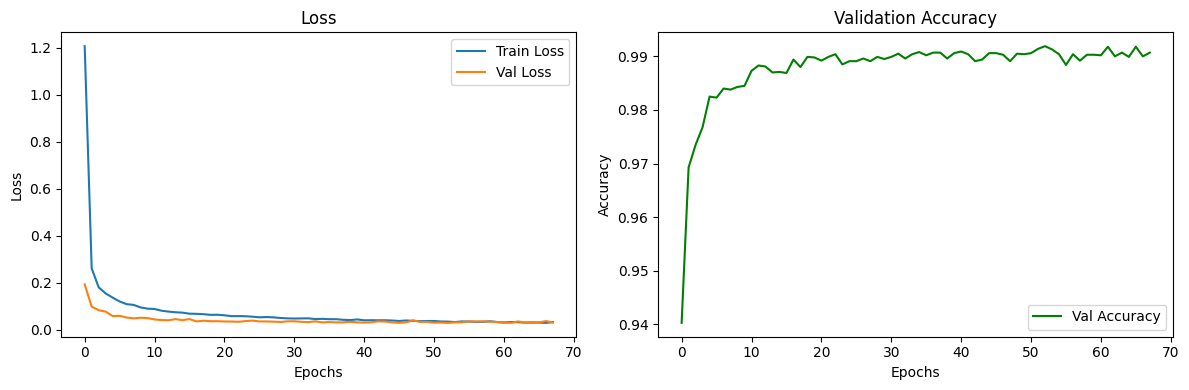

In [29]:
plot_loss_graph(history_train_loss, history_val_loss, history_val_metric)

In [30]:
# salvar o modelo treinado
torch.save(model_cnn.state_dict(), "best_cnn_mnist.pth")

### Comparação com a rede pré treinada e fine-tunning


In [65]:
# Carregar pré-treinada no ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Substituir a última camada: ImageNet tem 1000 classes, MNIST tem 10
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

In [66]:
from RepeatChannels import RepeatChannels

transform_mnist_for_resnet = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((224, 224)),
    RepeatChannels(3),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_data_resnet = datasets.MNIST(
    root="./../datasets",
    train=True,
    download=True,
    transform=transform_mnist_for_resnet
)
test_data_resnet = datasets.MNIST(
    root="./../datasets",
    train=False,
    download=True,
    transform=transform_mnist_for_resnet
)

In [67]:
train_data_resnet_split, val_data_resnet = split_train_val_dataset(train_data_resnet, val_size=1.0/6.0)

In [68]:
train_dataloader_resnet = DataLoader(train_data_resnet_split, batch_size=64, shuffle=True, num_workers=4, persistent_workers=True)
test_dataloader_resnet = DataLoader(test_data_resnet, batch_size=64, shuffle=False, num_workers=4, persistent_workers=True)
val_dataloader_resnet = DataLoader(val_data_resnet, batch_size=64, shuffle=False, num_workers=4, persistent_workers=True)

In [69]:
for param in resnet.parameters():
    param.requires_grad = False
resnet.fc.requires_grad_(True)  # só o classificador treina

loss_fn_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)
history_train_loss_resnet, history_val_loss_resnet, history_val_metric_resnet = train_model(
    resnet,
    train_dataloader_resnet,
    val_dataloader_resnet,
    loss_fn_resnet,
    optimizer_resnet,
    num_epochs=30,
    patience=3,
    metric_fn=metrics.accuracy_score,
    device=device,
    verbose=True
)

Epoch 1/30, Train Loss: 0.4348
Epoch 1/30, Validation Loss: 0.2109
Epoch 1/30, Validation Metric: 0.9429
Epoch 6/30, Train Loss: 0.1211
Epoch 6/30, Validation Loss: 0.1152
Epoch 6/30, Validation Metric: 0.9629
Epoch 11/30, Train Loss: 0.1009
Epoch 11/30, Validation Loss: 0.1126
Epoch 11/30, Validation Metric: 0.9630
Epoch 16/30, Train Loss: 0.0932
Epoch 16/30, Validation Loss: 0.1032
Epoch 16/30, Validation Metric: 0.9665


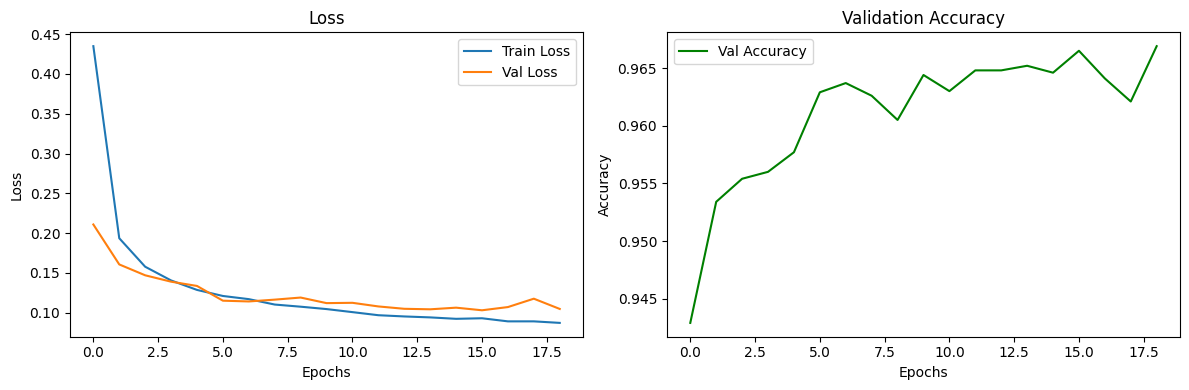

In [70]:
plot_loss_graph(history_train_loss_resnet, history_val_loss_resnet, history_val_metric_resnet)

In [71]:
resnet_mnist_test_accuracy = evaluate_model(resnet, test_dataloader_resnet, metric_fn=metrics.accuracy_score, device=device)
cnn_mnist_test_accuracy = evaluate_model(model_cnn, test_dataloader, metric_fn=metrics.accuracy_score, device=device)

print(f"CNN MNIST test accuracy: {cnn_mnist_test_accuracy:.4f}")
print(f"ResNet18 MNIST test accuracy: {resnet_mnist_test_accuracy:.4f}")

results_comparison_mnist = {
    'model': ['CNN customizada', 'ResNet18 fine-tuned'],
    'test_accuracy': [cnn_mnist_test_accuracy, resnet_mnist_test_accuracy],
}

results_comparison_mnist

CNN MNIST test accuracy: 0.9932
ResNet18 MNIST test accuracy: 0.9670


{'model': ['CNN customizada', 'ResNet18 fine-tuned'],
 'test_accuracy': [0.9932, 0.967]}

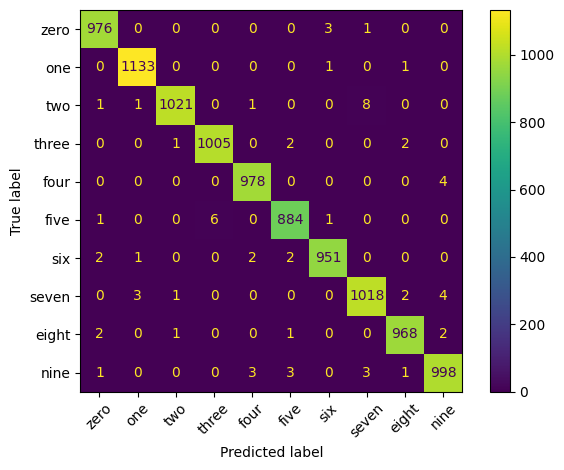

In [72]:
#plot confusion matrix para o modelo CNN customizado
class_names = [labels_map[i] for i in range(10)]
plot_confusion_matrix(model_cnn, test_dataloader, class_names, device)

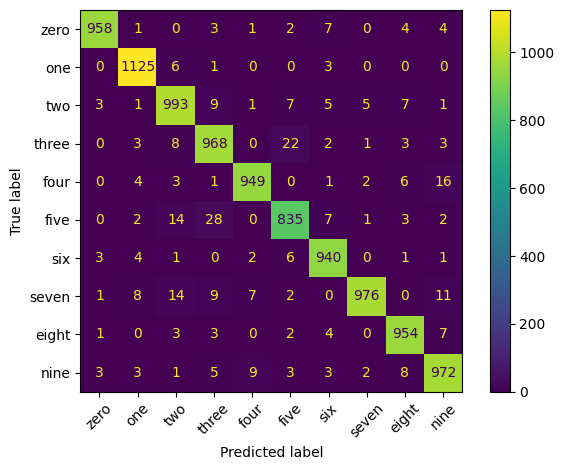

In [73]:
#plot confusion matrix para o modelo resnet
plot_confusion_matrix(resnet, test_dataloader_resnet, class_names, device)

## Visualização de ativações de kernels (DESAFIO)

CNN MNIST - Feature Maps da Primeira Camada Convolucional:


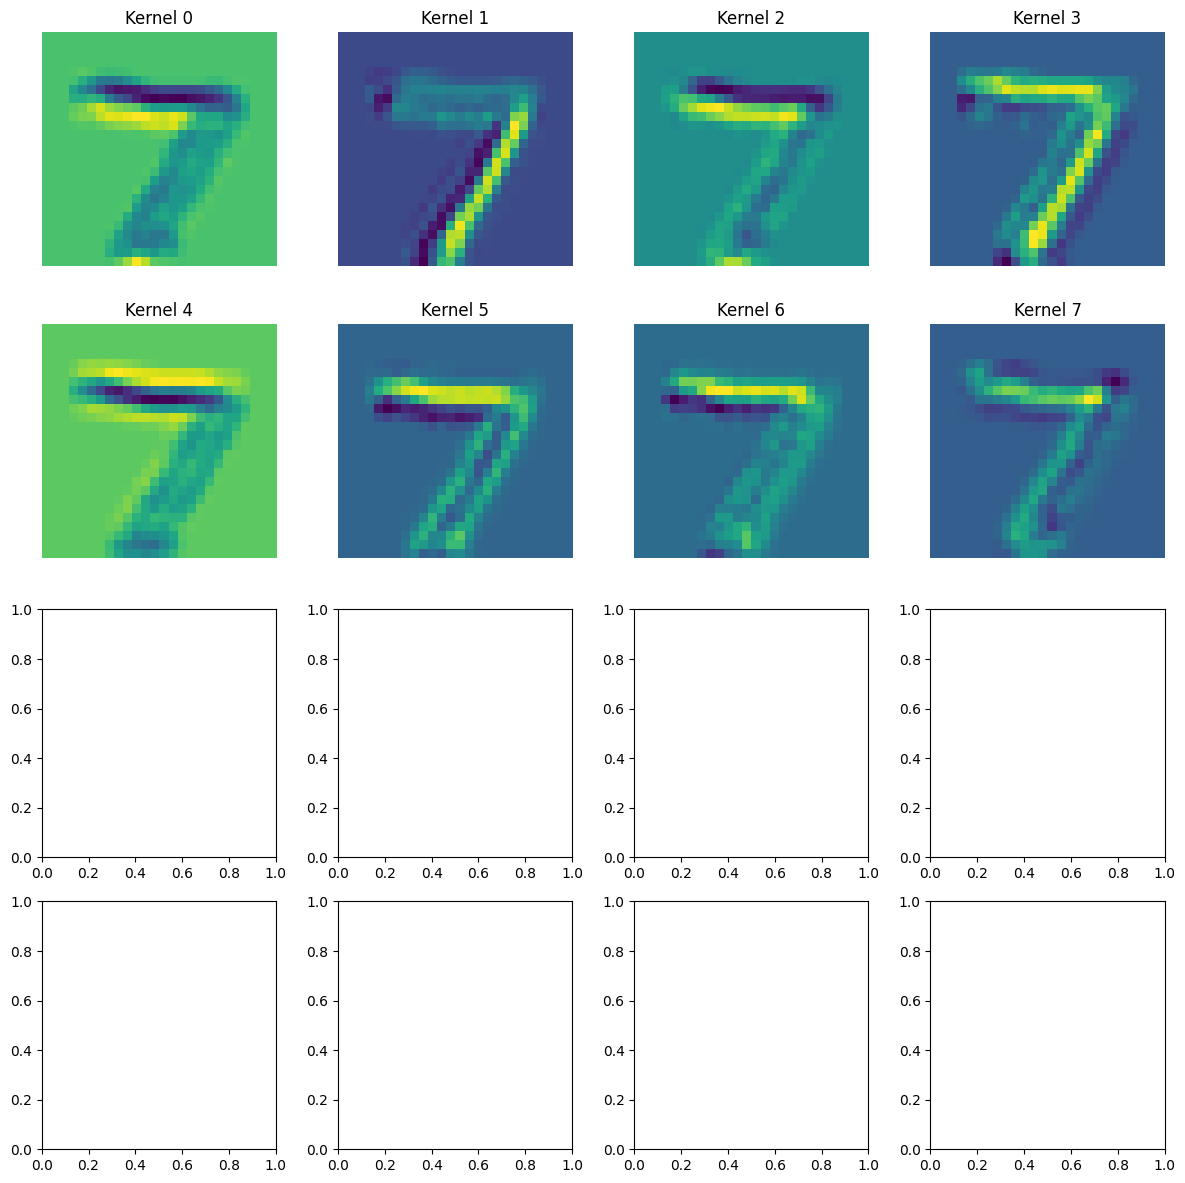

tensor([[[-0.0310, -0.0310, -0.0310,  ..., -0.0310, -0.0310, -0.0310],
         [-0.0310, -0.0310, -0.0310,  ..., -0.0310, -0.0310, -0.0310],
         [-0.0310, -0.0310, -0.0310,  ..., -0.0310, -0.0310, -0.0310],
         ...,
         [-0.0310, -0.0310, -0.0310,  ..., -0.0310, -0.0310, -0.0310],
         [-0.0310, -0.0310, -0.0310,  ..., -0.0310, -0.0310, -0.0310],
         [-0.0310, -0.0310, -0.0310,  ..., -0.0310, -0.0310, -0.0310]],

        [[-0.6113, -0.6113, -0.6113,  ..., -0.6113, -0.6113, -0.6113],
         [-0.6113, -0.6113, -0.6113,  ..., -0.6113, -0.6113, -0.6113],
         [-0.6113, -0.6113, -0.6113,  ..., -0.6113, -0.6113, -0.6113],
         ...,
         [-0.6113, -0.6113, -0.6113,  ..., -0.6113, -0.6113, -0.6113],
         [-0.6113, -0.6113, -0.6113,  ..., -0.6113, -0.6113, -0.6113],
         [-0.6113, -0.6113, -0.6113,  ..., -0.6113, -0.6113, -0.6113]],

        [[-0.0229, -0.0229, -0.0229,  ..., -0.0229, -0.0229, -0.0229],
         [-0.0229, -0.0229, -0.0229,  ..., -0

In [74]:
# Visualizar ativações de kernels do CNN customizado para MNIST
sample_image, sample_label = test_data[0]
sample_image = sample_image.unsqueeze(0)  # (1, 1, 28, 28)

# Visualizar primeira camada convolucional
print("CNN MNIST - Feature Maps da Primeira Camada Convolucional:")
visualize_feature_maps(model_cnn, sample_image, 'conv_layers.0', device)


## CIFAR10

### Download e preparação do dataset

In [13]:
train_cifar10_data = datasets.CIFAR10(
    root="./../datasets",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)
test_cifar10_data = datasets.CIFAR10(
    root="./../datasets",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)
train_cifar10_data_split, val_cifar10_data = split_train_val_dataset(train_cifar10_data, val_size=1.0/5.0)
print(f"Training set size: {len(train_cifar10_data_split)}")
print(f"Validation set size: {len(val_cifar10_data)}")
print(f"Test set size: {len(test_cifar10_data)}")

/home/bruno/ia_venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training set size: 40000
Validation set size: 10000
Test set size: 10000


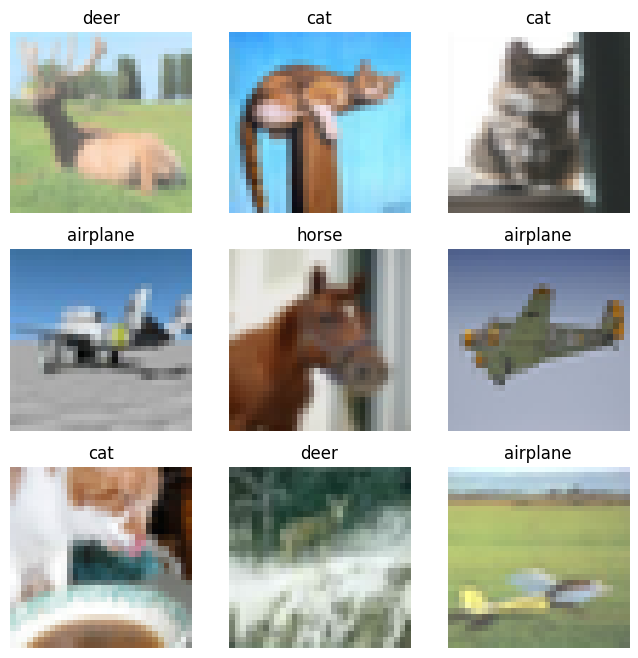

In [14]:
labels_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_cifar10_data_split), size=(1,)).item()
    img, label = train_cifar10_data_split[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()


### Função de otimização de hiperparâmetros e execução da busca do melhor modelo

In [77]:
def objectiveCIFAR10(trial):
    """
    Otimiza uma CNN pequena para CIFAR-10 procurando um compromisso entre
    melhor acurácia e menor complexidade do modelo.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)
    out_channels_list = []
    for i in range(num_conv_layers):
        out_channels = trial.suggest_categorical(f'out_channels_layer_{i}', [8, 16, 32, 64])
        out_channels_list.append(out_channels)

    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    stride_conv = trial.suggest_categorical('stride_conv', [1, 2])
    padding_conv = trial.suggest_categorical('padding_conv', [0, 1, 2])
    dilatation = 1
    bias = True

    use_pooling = trial.suggest_categorical('use_pooling', [True, False])
    kernel_stride_pool = 1
    kernel_padding_pool = 0
    kernel_dilatation_pool = 1

    activation_function_conv = trial.suggest_categorical('activation_function_conv', ['relu', 'leaky_relu', 'tanh'])
    use_dropout_conv = trial.suggest_categorical('use_dropout_conv', [True, False])
    if use_dropout_conv:
        dropout_rate_conv = trial.suggest_float('dropout_rate_conv', 0.1, 0.6)
    else:        
        dropout_rate_conv = 0.0

    num_fc_layers = trial.suggest_int('num_fc_layers', 1, 3)
    fully_connected_layers_list = []
    for i in range(num_fc_layers):
        fc_units = trial.suggest_categorical(f'fc_units_{i}', [16, 32, 64, 128, 256])
        fully_connected_layers_list.append(fc_units)

    activation_function_fc = trial.suggest_categorical('activation_function_fc', ['relu', 'leaky_relu', 'tanh', 'sigmoid'])
    use_dropout_fc = trial.suggest_categorical('use_dropout_fc', [True, False])
    if use_dropout_fc:
        dropout_rate_fc = trial.suggest_float('dropout_rate_fc', 0.1, 0.6)
    else:
        dropout_rate_fc = 0.0

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    use_weight_decay = trial.suggest_categorical('use_weight_decay', [True, False])
    if use_weight_decay:
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    else:
        weight_decay = 0.0
    num_epochs = 10000
    patience = 15

    try:
        img_shape = train_cifar10_data_split[0][0].shape  # (C, H, W)
        image_size_height=img_shape[1]
        image_size_width=img_shape[2]
        cnn_params = CNNParameters(
            num_conv_layers=num_conv_layers,
            stride_conv_layers=stride_conv,
            input_channels=3,
            out_channels_list=out_channels_list,
            use_pooling=use_pooling,
            padding_conv_layer=padding_conv,
            dilatation=dilatation,
            bias=bias,
            kernel_size=kernel_size,
            kernel_stride=kernel_stride_pool,
            kernel_padding=kernel_padding_pool,
            kernel_dilatation=kernel_dilatation_pool,
            activation_function_conv=activation_function_conv,
            fully_connected_layers_list=fully_connected_layers_list,
            activation_function_fully_connected=activation_function_fc,
            dropout_rate_fully_connected=dropout_rate_fc,
            dropout_rate_conv=dropout_rate_conv,
            output_size_fully_connected=10,
            image_size_height=image_size_height,
            image_size_width=image_size_width
        )

        if cnn_params.image_size_height_output <= 0 or cnn_params.image_size_width_output <= 0:
            return 0.0, float('inf')

        model, train_dataloader, test_dataloader, val_dataloader = create_model_and_dataloaders(
            cnn_params, train_cifar10_data_split, test_cifar10_data, val_cifar10_data, batch_size
        )
        model = model.to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer_cls = map_optimizers[optimizer_name]
        if optimizer_name == 'sgd':
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
        else:
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        history_train_loss, history_val_loss, history_val_metric = train_model(
            model,
            train_dataloader,
            val_dataloader,
            loss_fn,
            optimizer,
            num_epochs=num_epochs,
            patience=patience,
            metric_fn=metrics.accuracy_score,
            device=device,
        )

        val_accuracy = evaluate_model(model, val_dataloader, metric_fn=metrics.accuracy_score, device=device)
        flops = FlopCountAnalysis(model.cpu(), torch.randn(1, 3, 32, 32).cpu(),).total()

        return val_accuracy, flops

    except Exception as e:
        print(f"Erro durante a execução do trial: {e}")
        return 0.0, float('inf')

In [78]:
# Executar a otimização de hiperparâmetros com Optuna para CIFAR-10
SEED = 42
sampler = optuna.samplers.TPESampler(seed=SEED)
study_cifar10 = optuna.create_study(directions=['maximize', 'minimize'], sampler=sampler)
study_cifar10.optimize(objectiveCIFAR10, n_trials=25, show_progress_bar=True, n_jobs=1)

[I 2026-05-19 06:21:18,572] A new study created in memory with name: no-name-8a8c17d6-507c-4db1-802e-dca0f0699752


  0%|          | 0/25 [00:00<?, ?it/s]

Unsupported operator aten::tanh encountered 2 time(s)


[I 2026-05-19 06:25:15,811] Trial 0 finished with values: [0.1, 2814304.0] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 8, 'out_channels_layer_1': 32, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 0, 'use_pooling': False, 'activation_function_conv': 'tanh', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 256, 'activation_function_fc': 'relu', 'use_dropout_fc': True, 'dropout_rate_fc': 0.16101911742238942, 'batch_size': 128, 'learning_rate': 0.0061394260508981545, 'optimizer': 'rmsprop', 'use_weight_decay': False}.
[I 2026-05-19 06:25:15,817] Trial 1 finished with values: [0.0, inf] and parameters: {'num_conv_layers': 3, 'out_channels_layer_0': 8, 'out_channels_layer_1': 64, 'out_channels_layer_2': 32, 'kernel_size': 5, 'stride_conv': 2, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.27923286427213634, 'num_fc_layers': 1, 'fc_units_0': 16, 'activation_func

Unsupported operator aten::tanh encountered 4 time(s)


...

[I 2026-05-19 18:28:00,194] Trial 22 finished with values: [0.5916, 4338304.0] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 32, 'out_channels_layer_1': 8, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'num_fc_layers': 3, 'fc_units_0': 32, 'fc_units_1': 128, 'fc_units_2': 128, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.29079514648504945, 'batch_size': 32, 'learning_rate': 0.0002290857757760874, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 0.00012181589264726344}.


Unsupported operator aten::tanh encountered 2 time(s)


[I 2026-05-19 18:58:00,634] Trial 23 finished with values: [0.6269, 4370432.0] and parameters: {'num_conv_layers': 1, 'out_channels_layer_0': 64, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 128, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.10509661678846646, 'batch_size': 64, 'learning_rate': 0.0003870721696430466, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 9.171649188867916e-06}.


Unsupported operator aten::leaky_relu encountered 1 time(s)
Unsupported operator aten::tanh encountered 2 time(s)


[I 2026-05-19 19:08:37,579] Trial 24 finished with values: [0.6094, 3867968.0] and parameters: {'num_conv_layers': 1, 'out_channels_layer_0': 64, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 1, 'use_pooling': False, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 32, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.10464158889662503, 'batch_size': 32, 'learning_rate': 0.00016272281178345309, 'optimizer': 'adam', 'use_weight_decay': True, 'weight_decay': 1.0010897755397036e-05}.


In [79]:
# Mostrar a frente de Pareto encontrada
print("Trials não dominados:")
for trial in study_cifar10.best_trials:
    print(f"  acurácia={trial.values[0]:.4f}, complexidade={trial.values[1]:.4f}, params={trial.params}")

Trials não dominados:
  acurácia=0.5120, complexidade=219952.0000, params={'num_conv_layers': 1, 'out_channels_layer_0': 16, 'kernel_size': 3, 'stride_conv': 2, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.4509834386288517, 'num_fc_layers': 3, 'fc_units_0': 16, 'fc_units_1': 256, 'fc_units_2': 64, 'activation_function_fc': 'leaky_relu', 'use_dropout_fc': True, 'dropout_rate_fc': 0.36567731578407403, 'batch_size': 256, 'learning_rate': 0.0024744526814969676, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 1.1913852808702824e-06}
  acurácia=0.4913, complexidade=200496.0000, params={'num_conv_layers': 1, 'out_channels_layer_0': 16, 'kernel_size': 3, 'stride_conv': 2, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.12789524318021103, 'num_fc_layers': 2, 'fc_units_0': 16, 'fc_units_1': 64, 'activation_function_fc': 'leak

### Plots e treinamento do melhor modelo

In [80]:
fig = optuna.visualization.plot_param_importances(study_cifar10, target=lambda t: t.values[0], target_name="accuracy")
show(fig)

Best trial by accuracy: acurácia=0.6420, complexidade=14275200.0000, params={'num_conv_layers': 2, 'out_channels_layer_0': 32, 'out_channels_layer_1': 32, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 128, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.19583925932804302, 'batch_size': 32, 'learning_rate': 0.0001977314899753934, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 9.585545204800447e-05}


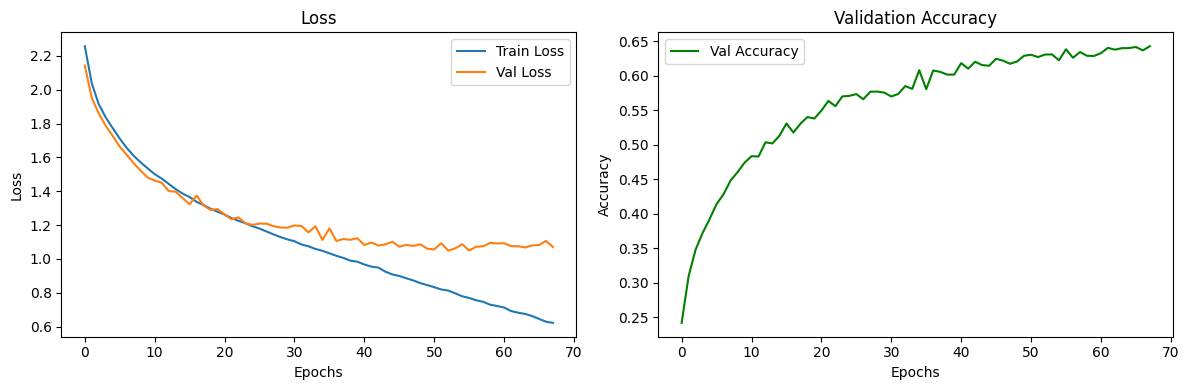

In [81]:
best_by_accuracy = max(study_cifar10.best_trials, key=lambda t: t.values[0])
print(f"Best trial by accuracy: acurácia={best_by_accuracy.values[0]:.4f}, complexidade={best_by_accuracy.values[1]:.4f}, params={best_by_accuracy.params}")

best_params = best_by_accuracy.params
cnn_params = CNNParameters(
            num_conv_layers=best_params['num_conv_layers'],
            stride_conv_layers=best_params['stride_conv'],
            input_channels=3,
            out_channels_list=[best_params[f'out_channels_layer_{i}'] for i in range(best_params['num_conv_layers'])],
            use_pooling=best_params['use_pooling'],
            padding_conv_layer=best_params['padding_conv'],
            dilatation=1,
            bias=True,
            kernel_size=best_params['kernel_size'],
            kernel_stride=1,
            kernel_padding=0,
            kernel_dilatation=1,
            activation_function_conv=best_params['activation_function_conv'],
            fully_connected_layers_list=[best_params[f'fc_units_{i}'] for i in range(best_params['num_fc_layers'])],
            activation_function_fully_connected=best_params['activation_function_fc'],
            dropout_rate_fully_connected=best_params['dropout_rate_fc'] if best_params['use_dropout_fc'] else 0.0,
            dropout_rate_conv=best_params['dropout_rate_conv'] if best_params['use_dropout_conv'] else 0.0,
            output_size_fully_connected=10,
            image_size_height=train_cifar10_data_split[0][0].shape[1],
            image_size_width=train_cifar10_data_split[0][0].shape[2]
        )

model_cnn_cifar10, train_dl_cifar10, test_dl_cifar10, val_dl_cifar10 = create_model_and_dataloaders(
            cnn_params, train_cifar10_data_split, test_cifar10_data, val_cifar10_data, best_params['batch_size']
        )
model_cnn_cifar10 = model_cnn_cifar10.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_cls = map_optimizers[best_params['optimizer']]
if best_params['optimizer'] == 'sgd':
    optimizer = optimizer_cls(model_cnn_cifar10.parameters(), lr=best_params['learning_rate'], momentum=0.9, weight_decay=best_params['weight_decay'] if best_params['use_weight_decay'] else 0.0)
else:
    optimizer = optimizer_cls(model_cnn_cifar10.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'] if best_params['use_weight_decay'] else 0.0)
history_train_loss, history_val_loss, history_val_metric = train_model(
            model_cnn_cifar10,
            train_dl_cifar10,
            val_dl_cifar10,
            loss_fn,
            optimizer,
            num_epochs=10000,
            patience=15,
            metric_fn=metrics.accuracy_score,
            device=device,
        )
plot_loss_graph(history_train_loss, history_val_loss, history_val_metric)

### Comparação com rede pré treinada e fine-tunning

In [16]:
transform_cifar10_for_resnet = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((224, 224)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_cifar10_resnet = datasets.CIFAR10(
    root="./../datasets",
    train=True,
    download=True,
    transform=transform_cifar10_for_resnet,
)
test_cifar10_resnet = datasets.CIFAR10(
    root="./../datasets",
    train=False,
    download=True,
    transform=transform_cifar10_for_resnet,
)
train_cifar10_resnet_split, val_cifar10_resnet = split_train_val_dataset(train_cifar10_resnet, val_size=1.0 / 5.0)

train_dataloader_cifar10_resnet = DataLoader(train_cifar10_resnet_split, batch_size=64, shuffle=True, num_workers=4, persistent_workers=True)
test_dataloader_cifar10_resnet = DataLoader(test_cifar10_resnet, batch_size=64, shuffle=False, num_workers=4, persistent_workers=True)
val_dataloader_cifar10_resnet = DataLoader(val_cifar10_resnet, batch_size=64, shuffle=False, num_workers=4, persistent_workers=True)

resnet_cifar10 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_cifar10.fc = nn.Linear(resnet_cifar10.fc.in_features, 10)
resnet_cifar10 = resnet_cifar10.to(device)

for param in resnet_cifar10.parameters():
    param.requires_grad = False
resnet_cifar10.fc.requires_grad_(True)

loss_fn_resnet_cifar10 = nn.CrossEntropyLoss()
optimizer_resnet_cifar10 = torch.optim.Adam(resnet_cifar10.fc.parameters(), lr=1e-3)

history_train_loss_resnet_cifar10, history_val_loss_resnet_cifar10, history_val_metric_resnet_cifar10 = train_model(
    resnet_cifar10,
    train_dataloader_cifar10_resnet,
    val_dataloader_cifar10_resnet,
    loss_fn_resnet_cifar10,
    optimizer_resnet_cifar10,
    num_epochs=30,
    patience=3,
    metric_fn=metrics.accuracy_score,
    device=device,
    verbose=True
)


/home/bruno/ia_venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 1/30, Train Loss: 0.8674
Epoch 1/30, Validation Loss: 0.6339
Epoch 1/30, Validation Metric: 0.7869
Epoch 6/30, Train Loss: 0.5676
Epoch 6/30, Validation Loss: 0.5523
Epoch 6/30, Validation Metric: 0.8086


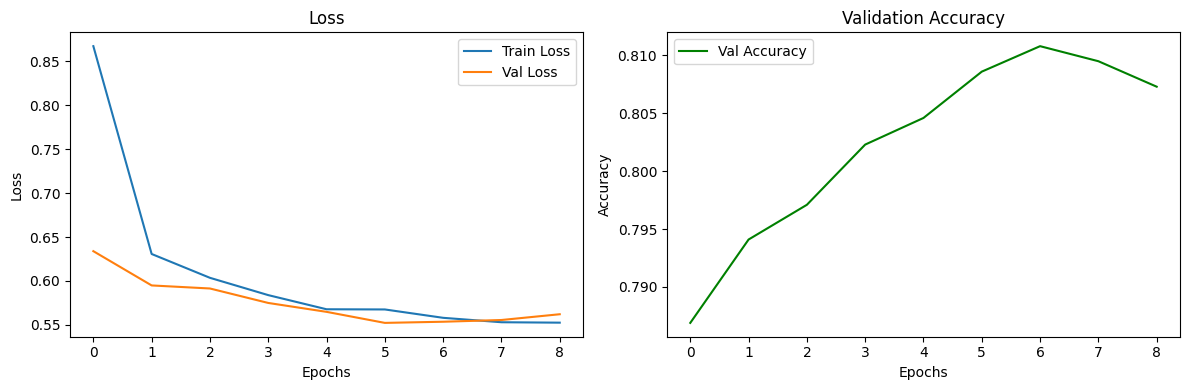

In [17]:
plot_loss_graph(
    history_train_loss_resnet_cifar10,
    history_val_loss_resnet_cifar10,
    history_val_metric_resnet_cifar10,
 )

In [21]:
cnn_cifar10_test_accuracy = evaluate_model(model_cnn_cifar10, test_dl_cifar10, metric_fn=metrics.accuracy_score, device=device)
resnet_cifar10_test_accuracy = evaluate_model(resnet_cifar10, test_dataloader_cifar10_resnet, metric_fn=metrics.accuracy_score, device=device)

print(f"CNN CIFAR10 test accuracy: {cnn_cifar10_test_accuracy:.4f}")
print(f"ResNet18 CIFAR10 test accuracy: {resnet_cifar10_test_accuracy:.4f}")

results_comparison_cifar10 = {
    'model': ['CNN customizada', 'ResNet18 fine-tuned'],
    'test_accuracy': [cnn_cifar10_test_accuracy, resnet_cifar10_test_accuracy],
}

results_comparison_cifar10

CNN CIFAR10 test accuracy: 0.6191
ResNet18 CIFAR10 test accuracy: 0.8008


{'model': ['CNN customizada', 'ResNet18 fine-tuned'],
 'test_accuracy': [0.6191, 0.8008]}

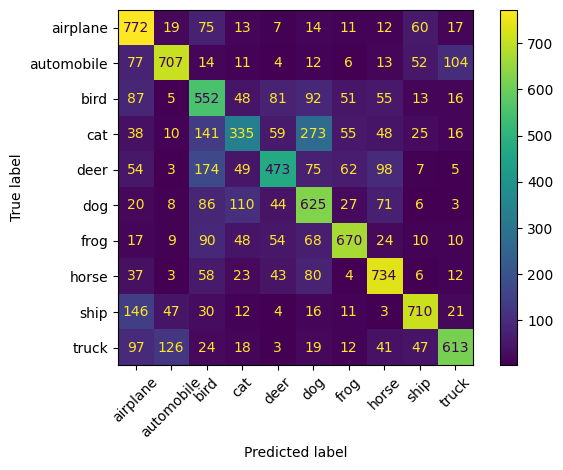

In [22]:
#plot confusion matrix para o modelo CNN customizado com cifar10
class_names = [labels_map[i] for i in range(10)]
plot_confusion_matrix(model_cnn_cifar10, test_dl_cifar10, class_names, device)

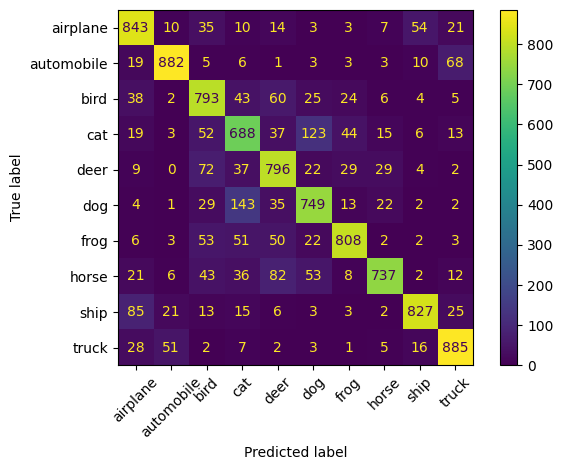

In [23]:
#plotar matriz de confusão para o modelo resnet com cifar10
plot_confusion_matrix(resnet_cifar10, test_dataloader_cifar10_resnet, class_names, device)

CNN CIFAR-10 - Feature Maps da Primeira Camada Convolucional:


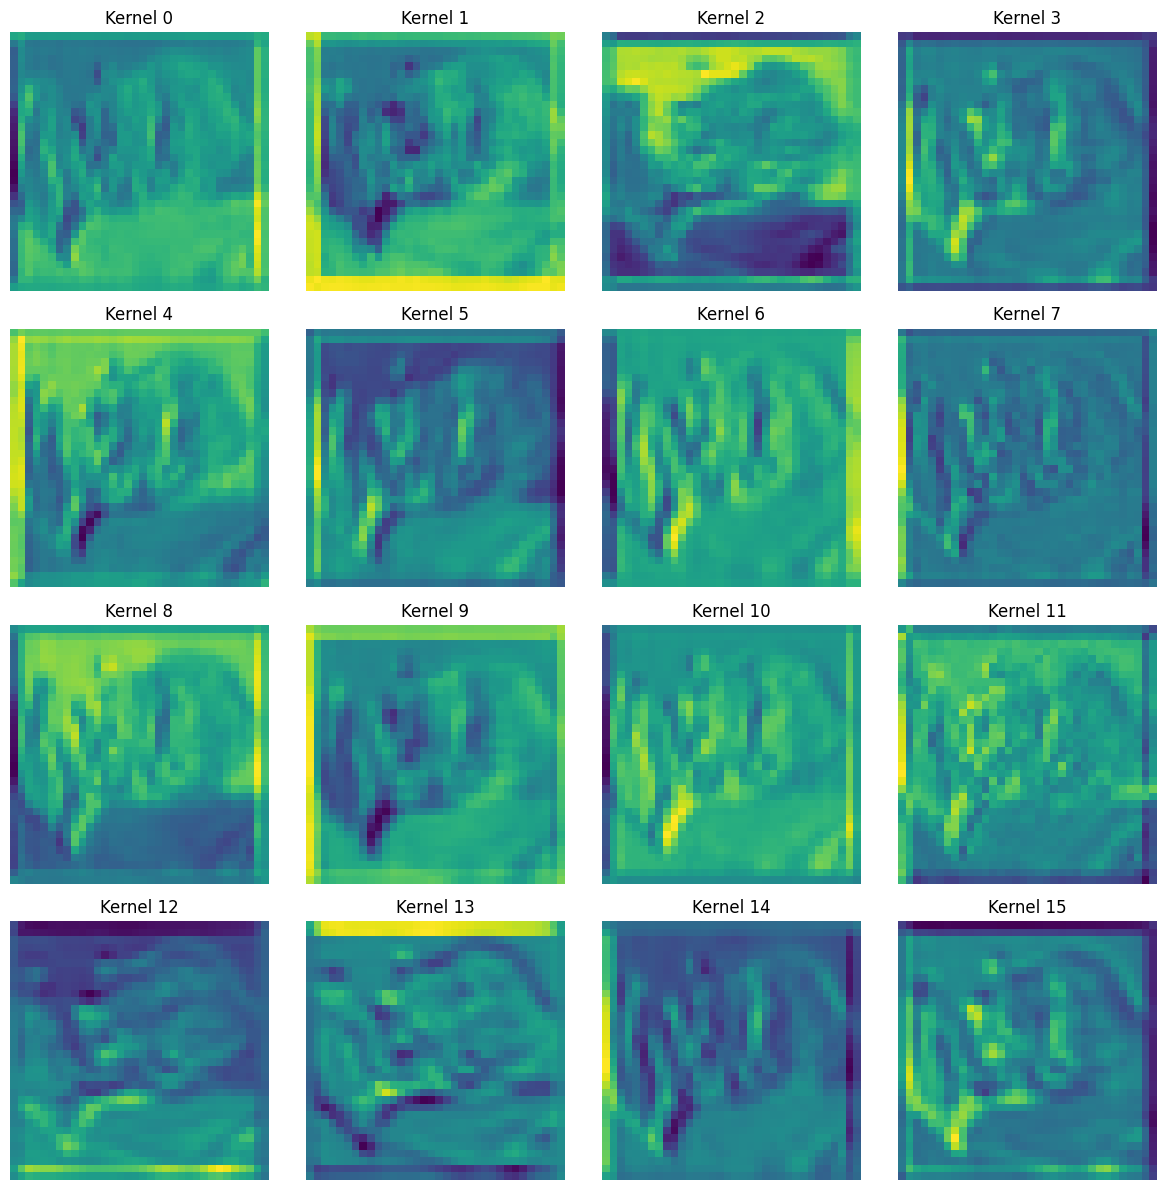

tensor([[[ 3.1761e-01,  3.4807e-01,  2.5647e-01,  ...,  2.8865e-01,
           3.6310e-01,  3.4333e-01],
         [ 5.5323e-02,  1.9902e-01,  4.5192e-02,  ...,  1.3028e-01,
           3.9966e-01,  3.0509e-01],
         [-8.6441e-02,  1.5978e-01,  7.7528e-02,  ...,  1.6700e-01,
           5.4187e-01,  3.7094e-01],
         ...,
         [-4.0398e-02,  4.0531e-01,  5.0791e-01,  ...,  5.0451e-01,
           7.2559e-01,  4.8934e-01],
         [ 7.9277e-02,  4.1191e-01,  4.1018e-01,  ...,  4.4606e-01,
           5.8350e-01,  3.8572e-01],
         [ 2.7036e-01,  3.2072e-01,  3.3680e-01,  ...,  3.4824e-01,
           4.2413e-01,  3.9736e-01]],

        [[-2.3495e-01, -2.1247e-01, -4.4620e-01,  ..., -3.9052e-01,
          -3.3626e-01, -3.4209e-01],
         [-3.5611e-01, -2.5019e-01, -5.7779e-01,  ..., -4.9750e-01,
          -3.5245e-01, -4.1962e-01],
         [-4.1083e-01, -3.2263e-01, -6.6405e-01,  ..., -5.8450e-01,
          -3.8624e-01, -4.3714e-01],
         ...,
         [-2.3238e-01, -2

In [24]:
# Visualizar ativações de kernels do CNN customizado para CIFAR-10
sample_image_cifar, sample_label_cifar = test_cifar10_data[0]
sample_image_cifar = sample_image_cifar.unsqueeze(0)  # (1, 3, 32, 32)

print("CNN CIFAR-10 - Feature Maps da Primeira Camada Convolucional:")
visualize_feature_maps(model_cnn_cifar10, sample_image_cifar, 'conv_layers.0', device)
